In [1]:
from senn.utils.stability_white_noise import compute_stability_adversarial, plot_input_comparison
from senn.models.senn import SENN
from senn.models.parameterizers import ConvParameterizer
from senn.models.conceptizers import ConvConceptizer
from senn.models.aggregators import SumAggregator
from pathlib import Path
from types import SimpleNamespace
import torch

## Load data and choose target image

In [2]:
config = {
    "train": False,
    "conceptizer": "ConvConceptizer",
    "image_size": 28,
    "concept_dim": 1,
    "parameterizer": "ConvParameterizer",
    "cl_sizes": [1, 10, 20],
    "hidden_sizes": [320, 50],
    "num_concepts": 5,
    "num_classes": 10,
    "dropout": 0.5,
    "aggregator": "SumAggregator",
    "device": "cpu",
    "lr": 2e-4,
    "epochs": 20,
    "robustness_loss": "mnist_robustness_loss",
    "robust_reg": 1e-2,
    "concept_reg": 1,
    "print_freq": 100,
    "exp_name": "fashion_mnist_lambda1e-2_c5_seed29",
    "dataloader": "fashion_mnist",
    "data_path": "datasets/data/fashion_mnist_data",
    "batch_size" : 200,
    "sparsity_reg" : 2e-5,
    "eval_freq" : 270,
    "manual_seed": 29
  }
  
config = SimpleNamespace(**config)

In [3]:
from senn.datasets.dataloaders import get_dataloader
train_dl, val_dl, test_dl = get_dataloader(config)

x_b, y_b = next(iter(test_dl))

In [4]:
mask_sneaker = (y_b == 7)
x_target = x_b[mask_sneaker][4]

## Load models

In [5]:
conceptizer= eval(config.conceptizer)(**config.__dict__)
parameterizer = eval(config.parameterizer)(**config.__dict__)
aggregator = eval(config.aggregator)(**config.__dict__)
model = SENN(conceptizer, parameterizer, aggregator)

In [6]:
checkpoint_path = Path('results')
model_file = checkpoint_path / config.exp_name / "checkpoints" / "best_model.pt" 
checkpoint = torch.load(model_file, map_location=config.device, weights_only=False)
print(f"Loading trained model: {model_file}")
model.load_state_dict(checkpoint['model_state'])

Loading trained model: results/fashion_mnist_lambda1e-2_c5_seed29/checkpoints/best_model.pt


<All keys matched successfully>

## Compute L_hat

In [7]:
# Define parameters
epsilon_ball = 0.05  # Max distance of perturbed pixels
n_steps = 30      

data_min = (0.0 - 0.2860) / 0.3530
data_max = (1.0 - 0.2860) / 0.3530

x_worst, L_hat_adv, pred_worst = compute_stability_adversarial(
    model=model,
    x_i=x_target,
    device=config.device,
    epsilon=epsilon_ball,
    steps=n_steps,
    use_fixed_class=True,
    data_min=data_min,
    data_max=data_max
)

# 3. Stampa i risultati
print(f"L_hat: {L_hat_adv:.6f}")
print(f"Prediction in worst case: {pred_worst}")

L_hat: 3.262734
Prediction in worst case: 7


/opt/anaconda3/envs/first/lib/python3.13/site-packages/torch/nn/functional.py:1545: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn(


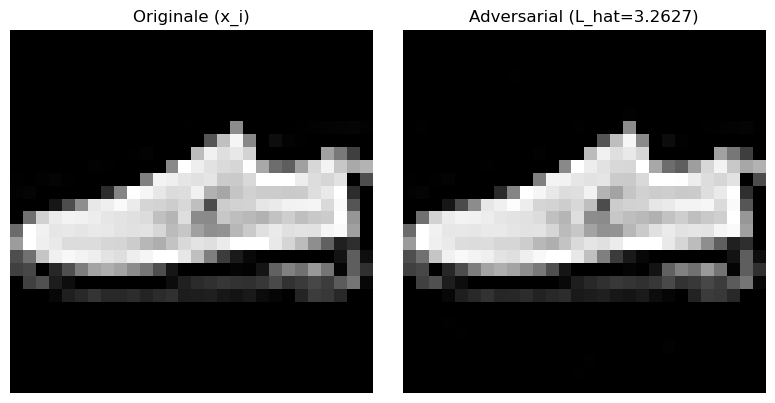

In [8]:
plot_input_comparison(x_target, x_worst, title_j=f"Adversarial (L_hat={L_hat_adv:.4f})")